# Personalization Impact — Reactivation Analysis for Long-Dormant Clients (Session/UTM-attributed method)

## What this notebook answers

Does the *type* of email/push campaign a client receives relate to whether they come back and buy something — and does that relationship change depending on how long the client has been away? Specifically: do personalized (APEC) sends show a meaningfully different reactivation rate than other campaign types, and how does that compare across clients who are recently lapsed vs. dormant for years?

This is an **observational comparison of existing send history** — it does not involve any new experiment or randomization. It tells us what's *associated* with reactivation historically, which is useful context on its own and also as a sanity check before committing to any further test. The comparison is descriptive throughout (rates with confidence intervals, no formal hypothesis tests) — with nine category-by-state groups, a pairwise significance test on any one pair wouldn't be the primary question here anyway.

## Population: three lifecycle states, one focus population

Every send in this analysis goes to a client who was already **Lapsed**, **Dormant**, or **Dormant 3+ years** *as of that specific send* (a client's state is evaluated at send time, not today). Active and Never Active clients are excluded entirely — they aren't the reactivation question this analysis is about.

| State | Days since last checkout |
|---|---|
| Lapsed | 121 – 365 |
| Dormant | 366 – 1,095 |
| **Dormant 3+ yrs (the focus population)** | 1,096+ |

**Dormant 3+ yrs is deliberately the decision-relevant population** — for a personalization system that relies on a history of client behavior, a client who hasn't interacted with the product in 3+ years is where that history (and therefore the personalization itself) is most likely to be stale or unavailable, making this the most informative group to check whether personalization is pulling its weight. Lapsed and Dormant are included alongside it, not as a second research question, but as context: they show how reactivation responsiveness changes across the dormancy spectrum, which matters for interpreting whether a weak Dormant 3+ yrs result reflects personalization specifically or just a population that's harder to reactivate no matter what it's sent.

## Campaign categories: how sends are classified

Campaigns are classified from the sent campaign's name (`send_utm_campaign` on the Blueshift send data), using pattern matching rather than a verified per-send flag, since no such flag exists in the data available. The mapping below is applied in full — a send is assigned to the first category it matches, checked in this order — so that every send lands somewhere specific and `OTHER` is a clean residual rather than a catch-all for categories that were never split out:

| Category | What it captures |
|---|---|
| **APEC** | Algorithmic Personalized Email Content — campaign names containing "apec", plus dormant/browse-abandon win-back triggers, StylePass onboarding messages, and style-profile reactivation pushes. |
| **TRANSACTIONAL** | Account-service email (password resets, order/Fix status confirmations, account alerts) — a client only receives these because they're already taking an action on their account, not because of a marketing choice. |
| **DSE** | Dynamic Shoppable Email, including its TFY and CYL content variants. |
| **PROMO_INCENTIVE** | Discount/promo/markdown/credit-driven sends (coupons, percent-off, last-chance, waived styling fee, and similar), plus a one-time mass "offertest" reactivation offer test that shares FLS's naming convention but isn't a behavioral trigger. |
| **FLS** | Freestyle Lifecycle Series — behaviorally triggered reminders after a high-intent event (e.g. cart abandonment, a saved item still available or newly on sale), identified by an explicit "freestyle-lifecycle" naming convention. |
| **TRACKING_ARTIFACT** | `crumbs_has_app` — a non-send tracking artifact, not a real campaign. |
| **WINBACK** | Explicit win-back/reactivation-named campaigns not already caught by APEC. |
| **BIRTHDAY** | Birthday-triggered sends. |
| **CROSSSELL** | Cross-sell campaigns. |
| **OTHER** | Everything else — generic marketing and seasonal content with no personalization-, promo-, or program-suggestive naming. |

**This analysis profiles only APEC, DSE, and OTHER** — the three categories the APEC personalization decision actually turns on. The other seven categories are still computed (so they're correctly pulled out of `OTHER` rather than inflating it) but aren't broken out individually here: TRANSACTIONAL, TRACKING_ARTIFACT, PROMO_INCENTIVE, WINBACK, BIRTHDAY, and FLS each run their own distinct program logic (or aren't a marketing lever at all), so they're out of scope for a comparison about APEC's personalization specifically.

## Reactivation metric: session/UTM-attributed

A client is counted as **reactivated** by a send if:
1. They visited the site or app via a session carrying UTM parameters matching that specific send (i.e., there's click-through evidence they actually engaged with it), **and**
2. That session is linked to a real demand event — a Fix request or a direct-buy order.

This is a stricter, more conservative standard than "a purchase happened sometime after the send" — it requires evidence the client actually engaged with *that* send, not just that they bought something in a nearby window for possibly unrelated reasons. The tradeoff: it will miss reactivations that happen through untracked paths (e.g., closing the email and returning later through the web browser with no tracked link), so observed rates here are a lower bound on true reactivation, not a precise count of it.

**Data recency:** the tables this metric relies on may take some time to fully reflect a send's outcome (e.g. session and demand data landing with a delay). To avoid comparing categories using data that hasn't finished settling, this analysis excludes very recent sends and only looks at a window of history old enough to have stabilized.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from amphibian import get_data_accessor
from statsmodels.stats.proportion import proportion_confint

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

def query(sql):
    return get_data_accessor(engines=['presto']).fetch_sql(sql=sql, error_on_empty=False)

# Population thresholds (days since last checkout)
ACTIVE_MAX_DAYS = 120
LAPSED_MAX_DAYS = 365
DORMANT_3YR_MIN_DAYS = 1095  # Dormant 3+ yrs is this analysis's focus population

# Send history window
START_DATE = '2025-01-01'
END_DATE = '2026-06-30'    # 18 months of history -- hardcoded for idempotent results, last day of a full month

# Reactivation metric
SESSION_ATTRIBUTION_WINDOW_DAYS = 7  # a session must land within this many days of the send to count as a match

# Statistics
ALPHA = 0.05

# Chart colors -- one ordinal blue ramp for the three lifecycle states (darker = more dormant),
# consistent across every chart in this notebook. Categories are shown via faceting, not color.
STATE_ORDER = ['Lapsed', 'Dormant', 'Dormant 3+ yrs']
STATE_COLORS = {
    'Lapsed':         '#86b6ef',
    'Dormant':        '#2a78d6',
    'Dormant 3+ yrs': '#104281',
}
CATEGORY_ORDER = ['APEC', 'DSE', 'OTHER']

print(f"Analysis window: {START_DATE} to {END_DATE}")

Analysis window: 2025-01-01 to 2026-06-30


## Step 1 — How many clients are we talking about?

Before comparing campaign types and states, a quick sanity check on the population itself: how many clients fall into each lifecycle bucket today, and specifically, how large is the Dormant 3+ years group this analysis focuses on.

In [2]:
lifecycle_bucket_query = f"""--sql
WITH journal AS (
    SELECT
        client_id,
        client_state_detail,
        date_diff('day', date(last_buyable_checkout_ts), current_date) AS days_since_last_checkout
    FROM curated.checkout_based_client_state_journal
    WHERE is_current = 1
)
SELECT
    CASE
        WHEN client_state_detail = 'Never Active' THEN 'Never Active'
        WHEN days_since_last_checkout <= {ACTIVE_MAX_DAYS} THEN 'Active'
        WHEN days_since_last_checkout <= {LAPSED_MAX_DAYS} THEN 'Lapsed'
        WHEN days_since_last_checkout <= {DORMANT_3YR_MIN_DAYS} THEN 'Dormant'
        ELSE 'Dormant 3+ yrs'
    END AS lifecycle_bucket,
    COUNT(*) AS n_clients
FROM journal
GROUP BY 1
ORDER BY n_clients DESC
"""

lifecycle_bucket_df = query(lifecycle_bucket_query)
lifecycle_bucket_df

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,lifecycle_bucket,n_clients
0,Never Active,37241392
1,Dormant 3+ yrs,9974636
2,Dormant,2038497
3,Active,1417668
4,Lapsed,912073


## Step 2 — The pipeline behind every number in this notebook

One query, grouped by month, campaign category, and lifecycle state:

1. **Find eligible sends**: sends to clients who were already Lapsed, Dormant, or Dormant 3+ years *at the time of the send* (not just today).
2. **Categorize each send** by its campaign name, using the full mapping above, then keep only APEC/DSE/OTHER.
3. **Match to a session**: did the client visit via a session carrying this send's UTM parameters, within `SESSION_ATTRIBUTION_WINDOW_DAYS`?
4. **Confirm demand**: did that session link to an actual Fix request or direct-buy order?

Each client is counted once per month per category per state — a client who received multiple sends in the same group in the same month is only counted as reactivated once, not once per send.

In [3]:
category_state_monthly_query = f"""--sql
WITH sends AS (
    SELECT client_id, sent_timestamp, send_utm_campaign, send_utm_content
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0 -- only include clients who were actually sent the campaign, not just targeted
),
state_sends AS (
    -- client's lifecycle state AS OF the send, not just today
    SELECT
        s.client_id, s.sent_timestamp, s.send_utm_campaign, s.send_utm_content,
        CASE
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {ACTIVE_MAX_DAYS} THEN 'Active'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {LAPSED_MAX_DAYS} THEN 'Lapsed'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {DORMANT_3YR_MIN_DAYS} THEN 'Dormant'
            ELSE 'Dormant 3+ yrs'
        END AS lifecycle_state
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
    WHERE j.client_state_detail != 'Never Active'
),
eligible_sends AS (
    SELECT client_id, sent_timestamp, send_utm_campaign, send_utm_content, lifecycle_state
    FROM state_sends
    WHERE lifecycle_state IN ('Lapsed', 'Dormant', 'Dormant 3+ yrs')
),
categorized_sends AS (
    -- full mapping, checked in order (first match wins), so OTHER is a clean residual
    SELECT
        client_id, sent_timestamp, send_utm_content, lifecycle_state,
        CASE
            WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%browseabandon%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%stylepass%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%styleprofile%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%transactional%' THEN 'TRANSACTIONAL'
            WHEN regexp_like(send_utm_campaign, '(^|_)dse(_|$)') THEN 'DSE'
            WHEN send_utm_campaign LIKE '%tfy%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%cyl%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%offertest%' THEN 'PROMO_INCENTIVE' -- shares FLS naming; one-time mass offer test, checked before FLS
            WHEN send_utm_campaign LIKE '%freestyle-lifecycle%' THEN 'FLS'
            WHEN send_utm_campaign LIKE '%freestyle_lifecycle%' THEN 'FLS'
            WHEN send_utm_campaign = 'crumbs_has_app' THEN 'TRACKING_ARTIFACT'
            WHEN send_utm_campaign LIKE '%offer%' OR send_utm_campaign LIKE '%discount%'
              OR send_utm_campaign LIKE '%promo%' OR send_utm_campaign LIKE '%sale%'
              OR send_utm_campaign LIKE '%percentoff%' OR send_utm_campaign LIKE '%markdown%'
              OR send_utm_campaign LIKE '%deal%' OR send_utm_campaign LIKE '%coupon%'
              OR send_utm_campaign LIKE '%spendget%' OR send_utm_campaign LIKE '%lastchance%'
              OR send_utm_campaign LIKE '%credit%' OR send_utm_campaign LIKE '%incentive%'
              OR send_utm_campaign LIKE '%waivedstylingfee%'
            THEN 'PROMO_INCENTIVE'
            WHEN send_utm_campaign LIKE '%reactivation%' OR send_utm_campaign LIKE '%winback%' THEN 'WINBACK'
            WHEN send_utm_campaign LIKE '%birthday%' THEN 'BIRTHDAY'
            WHEN send_utm_campaign LIKE '%crossell%' OR send_utm_campaign LIKE '%crosssell%' THEN 'CROSSSELL'
            ELSE 'OTHER'
        END AS campaign_category
    FROM eligible_sends
),
focus_sends AS (
    -- this analysis profiles only APEC, DSE, and OTHER -- see the category table above
    SELECT * FROM categorized_sends WHERE campaign_category IN ('APEC', 'DSE', 'OTHER')
),
matched_sessions AS (
    -- did the client visit via a session carrying this send's UTM parameters?
    SELECT c.client_id, c.sent_timestamp, c.lifecycle_state, c.campaign_category, u.active_session_id
    FROM focus_sends c
    INNER JOIN curated.user_session_conversion_metrics u
        ON u.client_id = c.client_id
        AND u.utm_source = 'blueshift'
        AND u.utm_content = c.send_utm_content
        AND u.datetime_in_utc >= c.sent_timestamp
        AND u.datetime_in_utc <  c.sent_timestamp + INTERVAL '{SESSION_ATTRIBUTION_WINDOW_DAYS}' DAY
    WHERE u.date_in_utc >= DATE '{START_DATE}'
),
attributed_demand AS (
    -- did that session lead to a real Fix or direct-buy demand event?
    SELECT DISTINCT ms.client_id, ms.sent_timestamp, ms.lifecycle_state, ms.campaign_category
    FROM matched_sessions ms
    INNER JOIN curated.client_reactivation_demand_events e
        ON e.active_session_id = ms.active_session_id
    WHERE e.demand_type IN ('fix', 'direct_buy')
),
client_month_category_state AS (
    -- one row per client per month per category per state: did they reactivate at all
    SELECT
        d.client_id,
        DATE_TRUNC('month', d.sent_timestamp) AS month,
        d.lifecycle_state,
        d.campaign_category,
        MAX(CASE WHEN a.client_id IS NOT NULL THEN 1 ELSE 0 END) AS client_reactivated
    FROM focus_sends d
    LEFT JOIN attributed_demand a
        ON d.client_id = a.client_id
        AND d.sent_timestamp = a.sent_timestamp
        AND d.lifecycle_state = a.lifecycle_state
        AND d.campaign_category = a.campaign_category
    GROUP BY 1, 2, 3, 4
)
SELECT
    month,
    campaign_category,
    lifecycle_state,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_month_category_state
GROUP BY 1, 2, 3
ORDER BY 2, 3, 1
"""

category_state_monthly_df = query(category_state_monthly_query)
category_state_monthly_df['month'] = pd.to_datetime(category_state_monthly_df['month'])
category_state_monthly_df.head()

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,month,campaign_category,lifecycle_state,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,2025-01-01,APEC,Dormant,654858,942,0.001438
1,2025-02-01,APEC,Dormant,638675,616,0.000964
2,2025-03-01,APEC,Dormant,633085,557,0.000880
3,2025-04-01,APEC,Dormant,617866,465,0.000753
4,2025-05-01,APEC,Dormant,604722,708,0.001171


## Reactivation rate and reach, by client state, per category

For each of the three focus categories, how does reactivation rate compare across Lapsed, Dormant, and Dormant 3+ yrs — and how much send volume is each state actually getting? Reading these two together is the point: if the population that reactivates best (Lapsed) is also the one that gets sent the least, and the population that reactivates worst (Dormant 3+ yrs) gets sent the most, that mismatch is itself part of the story.

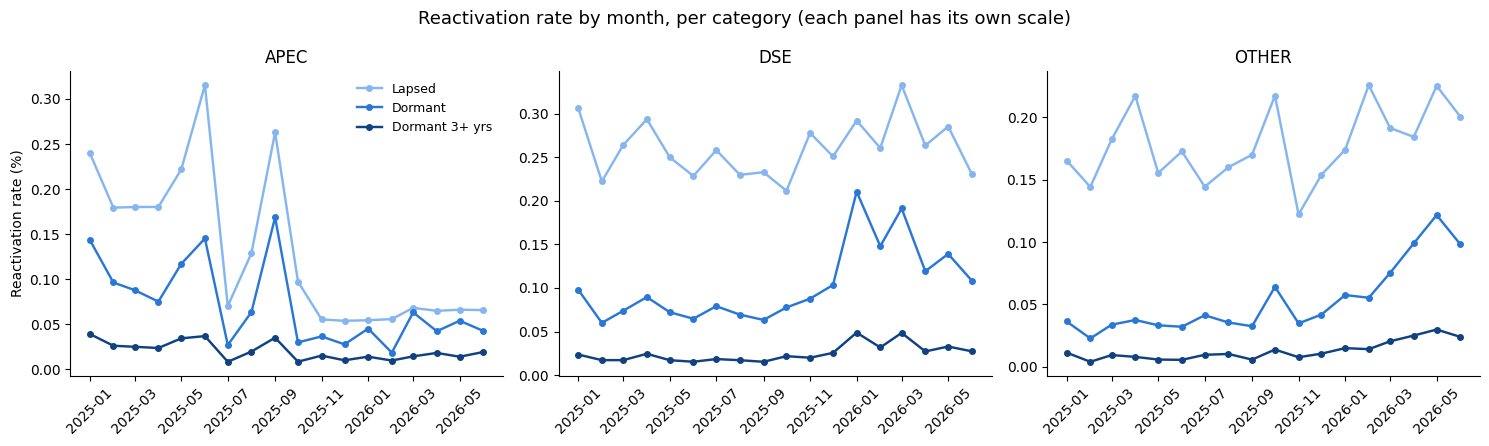

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

for ax, cat in zip(axes, CATEGORY_ORDER):
    cat_df = category_state_monthly_df[category_state_monthly_df['campaign_category'] == cat]
    for state in STATE_ORDER:
        state_df = cat_df[cat_df['lifecycle_state'] == state].sort_values('month')
        ax.plot(
            state_df['month'], state_df['client_reactivation_rate'] * 100,
            marker='o', markersize=4, linewidth=1.75, color=STATE_COLORS[state], label=state,
        )
    ax.set_title(cat, fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelrotation=45)

axes[0].set_ylabel('Reactivation rate (%)')
axes[0].legend(frameon=False, loc='upper right', fontsize=9)
fig.suptitle('Reactivation rate by month, per category (each panel has its own scale)', fontsize=13)
plt.tight_layout()
plt.show()

**Reach**, for the same three categories and states — this is what determines how much any of the rates above actually matters in absolute terms.

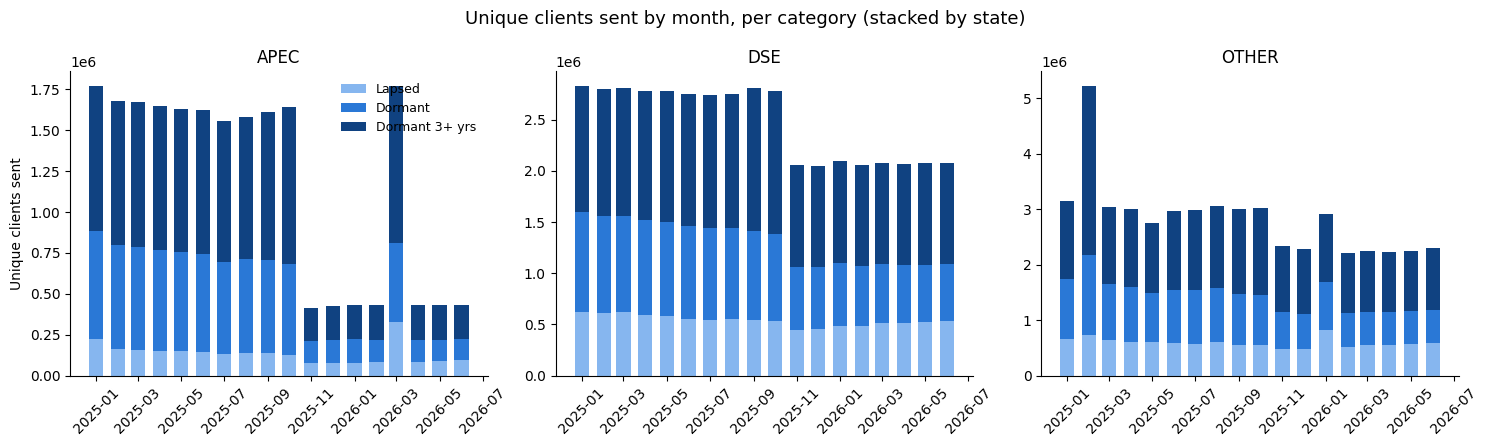

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

for ax, cat in zip(axes, CATEGORY_ORDER):
    cat_df = category_state_monthly_df[category_state_monthly_df['campaign_category'] == cat]
    pivot = cat_df.pivot(index='month', columns='lifecycle_state', values='unique_clients_sent').sort_index()
    pivot = pivot.reindex(columns=STATE_ORDER)
    bottom = None
    for state in STATE_ORDER:
        values = pivot[state].fillna(0)
        ax.bar(
            pivot.index, values, bottom=bottom, width=20,
            color=STATE_COLORS[state], label=state,
        )
        bottom = values if bottom is None else bottom + values
    ax.set_title(cat, fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelrotation=45)

axes[0].set_ylabel('Unique clients sent')
axes[0].legend(frameon=False, loc='upper right', fontsize=9)
fig.suptitle('Unique clients sent by month, per category (stacked by state)', fontsize=13)
plt.tight_layout()
plt.show()

## Full-window summary

The charts above pool into monthly numbers; this table pools across the entire window instead, so each client is counted once per category-state group regardless of how many months they were sent. Rates include Wilson 95% confidence intervals but no formal pairwise significance testing — with nine category-by-state groups, a single pairwise test wouldn't answer the actual question here (where is reactivation concentrated), and would need a multiple-comparison correction to mean anything across all of them.

In [6]:
category_state_summary_query = f"""--sql
WITH sends AS (
    SELECT client_id, sent_timestamp, send_utm_campaign, send_utm_content
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0
),
state_sends AS (
    SELECT
        s.client_id, s.sent_timestamp, s.send_utm_campaign, s.send_utm_content,
        CASE
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {ACTIVE_MAX_DAYS} THEN 'Active'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {LAPSED_MAX_DAYS} THEN 'Lapsed'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {DORMANT_3YR_MIN_DAYS} THEN 'Dormant'
            ELSE 'Dormant 3+ yrs'
        END AS lifecycle_state
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
    WHERE j.client_state_detail != 'Never Active'
),
eligible_sends AS (
    SELECT client_id, sent_timestamp, send_utm_campaign, send_utm_content, lifecycle_state
    FROM state_sends
    WHERE lifecycle_state IN ('Lapsed', 'Dormant', 'Dormant 3+ yrs')
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, send_utm_content, lifecycle_state,
        CASE
            WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%browseabandon%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%stylepass%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%styleprofile%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%transactional%' THEN 'TRANSACTIONAL'
            WHEN regexp_like(send_utm_campaign, '(^|_)dse(_|$)') THEN 'DSE'
            WHEN send_utm_campaign LIKE '%tfy%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%cyl%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%offertest%' THEN 'PROMO_INCENTIVE'
            WHEN send_utm_campaign LIKE '%freestyle-lifecycle%' THEN 'FLS'
            WHEN send_utm_campaign LIKE '%freestyle_lifecycle%' THEN 'FLS'
            WHEN send_utm_campaign = 'crumbs_has_app' THEN 'TRACKING_ARTIFACT'
            WHEN send_utm_campaign LIKE '%offer%' OR send_utm_campaign LIKE '%discount%'
              OR send_utm_campaign LIKE '%promo%' OR send_utm_campaign LIKE '%sale%'
              OR send_utm_campaign LIKE '%percentoff%' OR send_utm_campaign LIKE '%markdown%'
              OR send_utm_campaign LIKE '%deal%' OR send_utm_campaign LIKE '%coupon%'
              OR send_utm_campaign LIKE '%spendget%' OR send_utm_campaign LIKE '%lastchance%'
              OR send_utm_campaign LIKE '%credit%' OR send_utm_campaign LIKE '%incentive%'
              OR send_utm_campaign LIKE '%waivedstylingfee%'
            THEN 'PROMO_INCENTIVE'
            WHEN send_utm_campaign LIKE '%reactivation%' OR send_utm_campaign LIKE '%winback%' THEN 'WINBACK'
            WHEN send_utm_campaign LIKE '%birthday%' THEN 'BIRTHDAY'
            WHEN send_utm_campaign LIKE '%crossell%' OR send_utm_campaign LIKE '%crosssell%' THEN 'CROSSSELL'
            ELSE 'OTHER'
        END AS campaign_category
    FROM eligible_sends
),
focus_sends AS (
    SELECT * FROM categorized_sends WHERE campaign_category IN ('APEC', 'DSE', 'OTHER')
),
matched_sessions AS (
    SELECT c.client_id, c.sent_timestamp, c.lifecycle_state, c.campaign_category, u.active_session_id
    FROM focus_sends c
    INNER JOIN curated.user_session_conversion_metrics u
        ON u.client_id = c.client_id
        AND u.utm_source = 'blueshift'
        AND u.utm_content = c.send_utm_content
        AND u.datetime_in_utc >= c.sent_timestamp
        AND u.datetime_in_utc <  c.sent_timestamp + INTERVAL '{SESSION_ATTRIBUTION_WINDOW_DAYS}' DAY
    WHERE u.date_in_utc >= DATE '{START_DATE}'
),
attributed_demand AS (
    SELECT DISTINCT ms.client_id, ms.sent_timestamp, ms.lifecycle_state, ms.campaign_category
    FROM matched_sessions ms
    INNER JOIN curated.client_reactivation_demand_events e
        ON e.active_session_id = ms.active_session_id
    WHERE e.demand_type IN ('fix', 'direct_buy')
),
client_category_state AS (
    -- one row per client per category per state: did they reactivate at all, anytime in the window
    SELECT
        d.client_id,
        d.lifecycle_state,
        d.campaign_category,
        MAX(CASE WHEN a.client_id IS NOT NULL THEN 1 ELSE 0 END) AS client_reactivated
    FROM focus_sends d
    LEFT JOIN attributed_demand a
        ON d.client_id = a.client_id
        AND d.sent_timestamp = a.sent_timestamp
        AND d.lifecycle_state = a.lifecycle_state
        AND d.campaign_category = a.campaign_category
    GROUP BY 1, 2, 3
)
SELECT
    campaign_category,
    lifecycle_state,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_category_state
GROUP BY 1, 2
ORDER BY 1, 2
"""

category_state_summary_df = query(category_state_summary_query)
category_state_summary_df[['ci_low', 'ci_high']] = category_state_summary_df.apply(
    lambda r: pd.Series(proportion_confint(r['reactivated_clients'], r['unique_clients_sent'], alpha=ALPHA, method='wilson')),
    axis=1,
)
category_state_summary_df['rate_display'] = category_state_summary_df.apply(
    lambda r: f"{r['client_reactivation_rate']:.4%}  ({r['ci_low']:.4%} - {r['ci_high']:.4%})", axis=1
)
category_state_summary_df[['campaign_category', 'lifecycle_state', 'unique_clients_sent', 'reactivated_clients', 'rate_display']]

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,campaign_category,lifecycle_state,unique_clients_sent,reactivated_clients,rate_display
0,APEC,Dormant,1153241,6448,0.5591% (0.5457% - 0.5729%)
1,APEC,Dormant 3+ yrs,1362249,2631,0.1931% (0.1859% - 0.2007%)
2,APEC,Lapsed,756568,3450,0.4560% (0.4411% - 0.4714%)
3,DSE,Dormant,1686563,13222,0.7840% (0.7708% - 0.7974%)
4,DSE,Dormant 3+ yrs,1866611,5009,0.2683% (0.2610% - 0.2759%)
5,DSE,Lapsed,1735120,24141,1.3913% (1.3740% - 1.4089%)
6,OTHER,Dormant,2422393,7338,0.3029% (0.2961% - 0.3099%)
7,OTHER,Dormant 3+ yrs,3753853,2919,0.0778% (0.0750% - 0.0806%)
8,OTHER,Lapsed,2167574,18422,0.8499% (0.8378% - 0.8622%)


## Limitations to keep in mind

- **Observational, not causal.** Nothing here is randomized. If APEC, DSE, and OTHER sends go to different sub-segments of a given state, are sent at different frequencies, or through different channels, some of any observed gap could reflect those differences rather than the campaign type itself.
- **The reactivation metric is a lower bound.** It only counts reactivation with click-through evidence (a UTM-matched session). Real reactivations that happen through untracked paths — closing the email and returning later through the app, for instance — aren't counted. This affects all categories and states, but the *size* of that undercount could differ across them if, say, app usage patterns differ by dormancy length.
- **The granular mapping is computed in full but only three categories are shown.** TRANSACTIONAL, TRACKING_ARTIFACT, PROMO_INCENTIVE, WINBACK, BIRTHDAY, and FLS are each correctly pulled out of the population before `OTHER` is computed, but aren't individually profiled here — each runs its own distinct program logic (or, for TRANSACTIONAL, isn't a marketing send at all), so they're out of scope for a comparison about APEC's personalization specifically.
- **Lapsed and Dormant are context, not the decision population.** They're included to show how reactivation responsiveness changes across the dormancy spectrum, which helps interpret the Dormant 3+ yrs numbers — but the APEC/CTSM-embedding decision this analysis supports is scoped to Dormant 3+ yrs.
- **`END_DATE` relies on a 45-day maturity assumption that is *not independently confirmed* for this notebook's data sources** (`user_session_conversion_metrics`, `client_reactivation_demand_events`) — that window is only confirmed for a different table's send-attributed outcome flags. The most recent 1-2 months in this window deserve slightly more caution than the rest.